In [1]:
from google.colab import files
files.upload()

Saving plp.txt to plp.txt


{'plp.txt': b'export KAGGLE_API_TOKEN=KGAT_dbe69d9a02fbe0c92b0239c131750a8c'}

In [3]:
import os
import shutil
import json

# Extract token from the uploaded kaggle token.txt file
# Updated filename from 'kaggle token.txt' to 'plp.txt'
with open('plp.txt', 'r') as f:
    content = f.read()
    # Assuming format: export KAGGLE_API_TOKEN=...
    token = content.split('=')[-1].strip()

# Create the kaggle.json file (Kaggle expects {"username":"...","key":"..."})
# Note: Replace 'YOUR_KAGGLE_USERNAME' with your actual Kaggle username
kaggle_data = {"username": "YOUR_KAGGLE_USERNAME", "key": token}

with open('kaggle.json', 'w') as f:
    json.dump(kaggle_data, f)

# Setup the directory
os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle configuration complete. Please ensure you replace 'YOUR_KAGGLE_USERNAME' with your actual Kaggle username in the code if required.")

Kaggle configuration complete. Please ensure you replace 'YOUR_KAGGLE_USERNAME' with your actual Kaggle username in the code if required.


In [4]:
!kaggle datasets download -d therealoise/bean-disease-dataset

Dataset URL: https://www.kaggle.com/datasets/therealoise/bean-disease-dataset
License(s): CC0-1.0
100% 131M/131M [00:04<00:00, 28.9MB/s]



In [5]:
!unzip -q bean-disease-dataset.zip

In [6]:
import os

print(os.listdir())

['.config', 'bean-disease-dataset.zip', 'Bean_Dataset', 'plp.txt', 'sample_data']


In [7]:
dataset_path = "Bean_Dataset"

# Check the contents of the dataset directory
if os.path.exists(dataset_path):
    print(f"Contents of {dataset_path}:")
    print(os.listdir(dataset_path))
else:
    print(f"Directory {dataset_path} not found.")

Contents of Bean_Dataset:
['bean_rust', 'angular_leaf_spot', 'healthy']


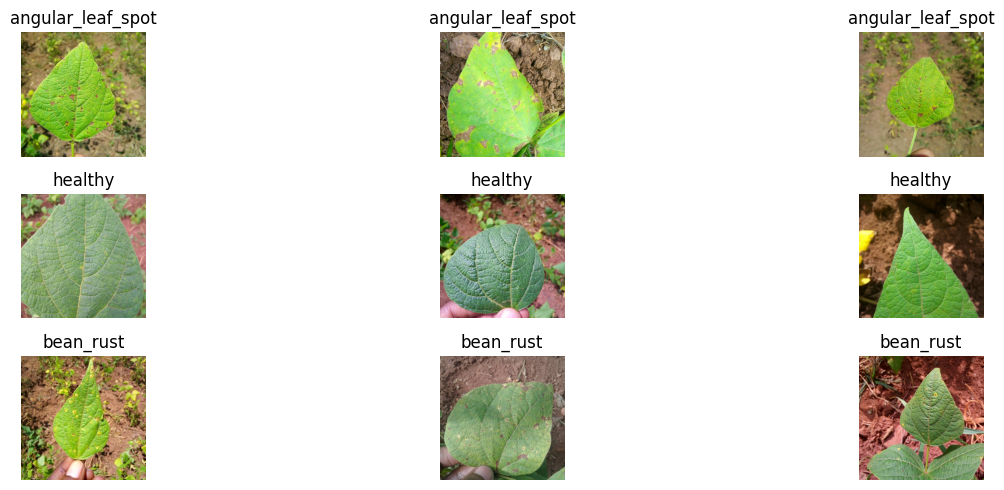

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def display_samples(base_path, categories, n=3):
    plt.figure(figsize=(15, 5))
    for i, category in enumerate(categories):
        category_path = os.path.join(base_path, category)
        images = os.listdir(category_path)
        selected_images = random.sample(images, min(n, len(images)))

        for j, img_name in enumerate(selected_images):
            plt.subplot(len(categories), n, i * n + j + 1)
            img = mpimg.imread(os.path.join(category_path, img_name))
            plt.imshow(img)
            plt.title(category)
            plt.axis('off')
    plt.tight_layout()
    plt.show()

categories = ['angular_leaf_spot', 'healthy', 'bean_rust']
display_samples(dataset_path, categories)

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
dataset_path = "Bean_Dataset"

classes = sorted(os.listdir(dataset_path))

print("Dataset Path:", dataset_path)
print("Classes:", classes)
print("Number of Classes:", len(classes))

Dataset Path: Bean_Dataset
Classes: ['angular_leaf_spot', 'bean_rust', 'healthy']
Number of Classes: 3


In [11]:
image_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    image_counts[cls] = len(os.listdir(class_path))

image_counts

{'angular_leaf_spot': 330, 'bean_rust': 330, 'healthy': 330}

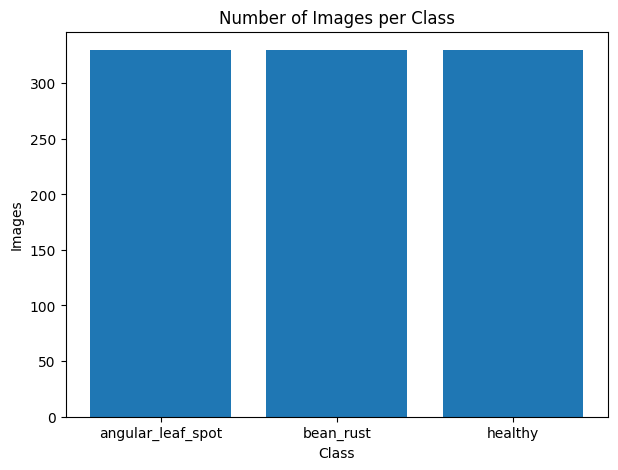

In [12]:
plt.figure(figsize=(7,5))
plt.bar(image_counts.keys(), image_counts.values())
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Images")
plt.show()

In [13]:
df = pd.DataFrame({
    "Class": image_counts.keys(),
    "Images": image_counts.values()
})

df

,Class,Images
0,angular_leaf_spot,330
1,bean_rust,330
2,healthy,330


In [14]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Rescaling
import tensorflow as tf

In [15]:
import os

os.listdir("/content")

['.config',
 'bean-disease-dataset.zip',
 'Bean_Dataset',
 'plp.txt',
 'sample_data']

In [16]:
dataset_path = "Bean_Dataset"

In [17]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

In [18]:
train_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 990 files belonging to 3 classes.
Using 693 files for training.
Found 990 files belonging to 3 classes.
Using 297 files for validation.


In [19]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
EPOCHS = 10
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 371ms/step - accuracy: 0.4271 - loss: 1.5183 - val_accuracy: 0.5354 - val_loss: 0.9205
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.6219 - loss: 0.8319 - val_accuracy: 0.6667 - val_loss: 0.7925
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.6739 - loss: 0.7198 - val_accuracy: 0.7205 - val_loss: 0.7065
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.7186 - loss: 0.6231 - val_accuracy: 0.7677 - val_loss: 0.6784
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.7980 - loss: 0.5171 - val_accuracy: 0.7508 - val_loss: 0.5915
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.8442 - loss: 0.4055 - val_accuracy: 0.7374 - val_loss: 0.6983
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - accuracy: 0.8802 - loss: 0.3057 - val_accuracy: 0.7374 - val_loss: 0.6284
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.9221 - loss: 0.2156 - val_accuracy: 0

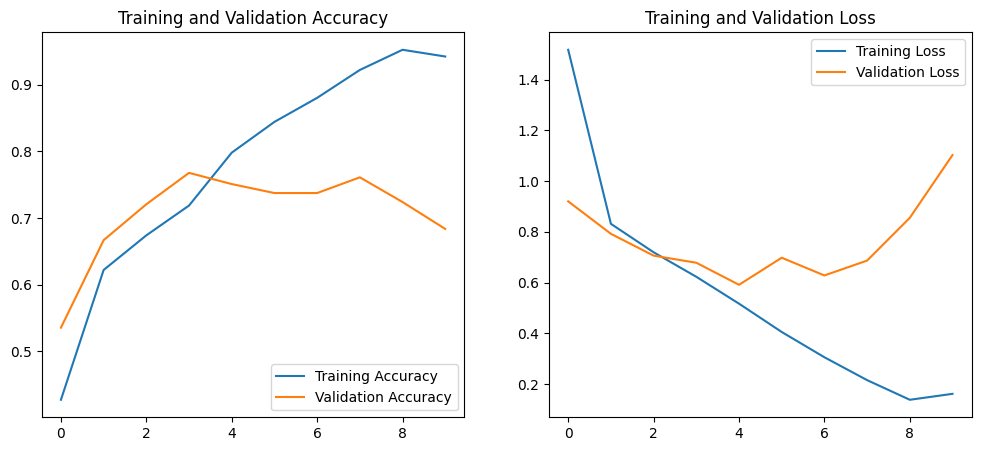

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')
plt.show()

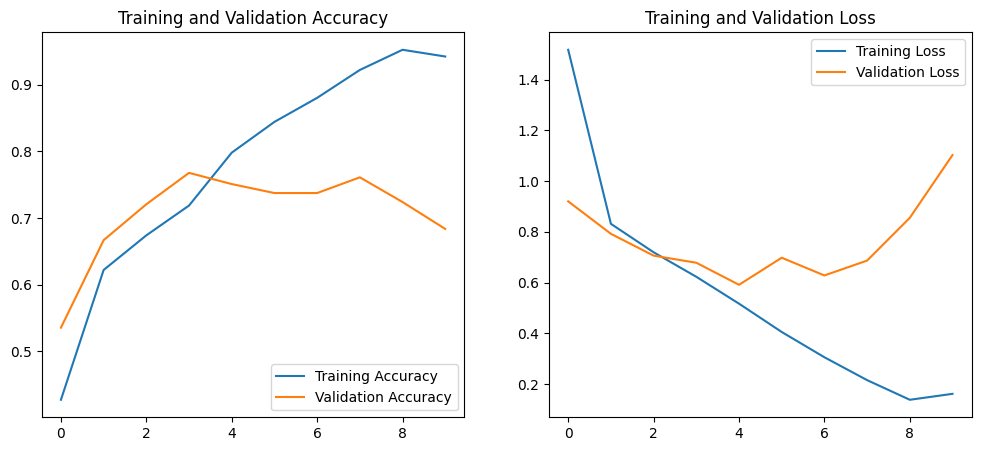

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')
plt.show()

In [23]:
val_test_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 990 files belonging to 3 classes.
Using 297 files for validation.


In [24]:
val_batches = tf.data.experimental.cardinality(val_test_dataset)

test_dataset = val_test_dataset.take(val_batches // 2)

validation_dataset = val_test_dataset.skip(val_batches // 2)

In [25]:
class_names = train_dataset.class_names

print(class_names)

['angular_leaf_spot', 'bean_rust', 'healthy']


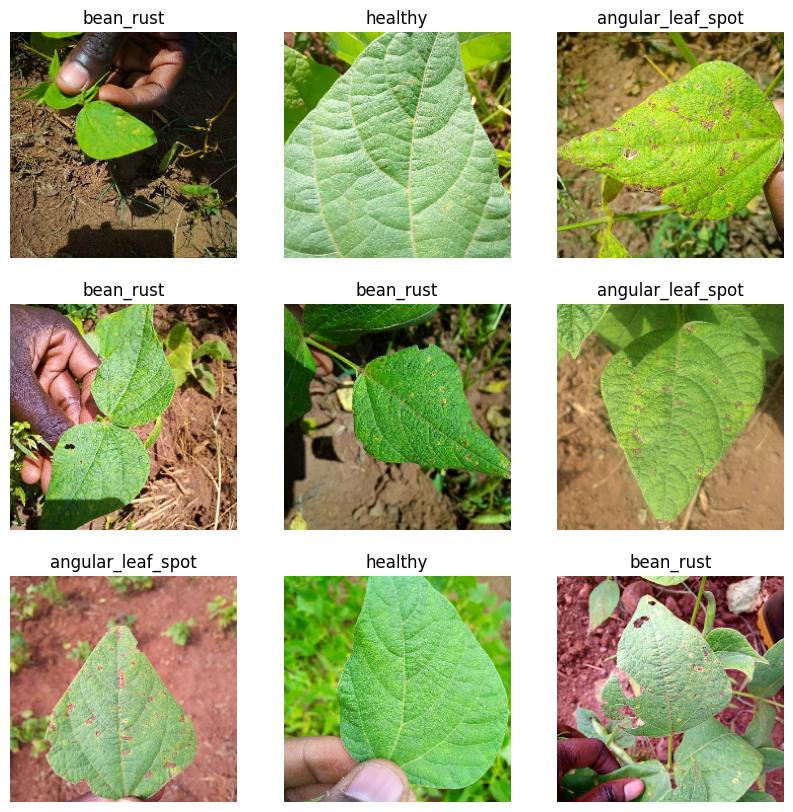

In [26]:
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [27]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [28]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

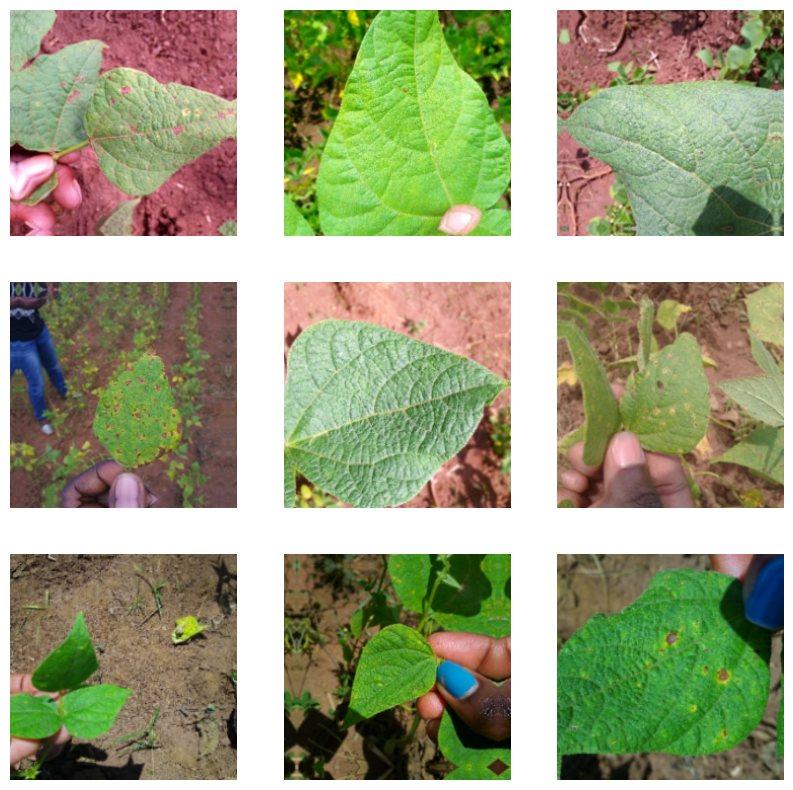

In [29]:
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(10,10))

    for i in range(9):
        augmented = data_augmentation(images[i])

        plt.subplot(3,3,i+1)
        plt.imshow(augmented.numpy().astype("uint8"))
        plt.axis("off")

plt.show()

In [30]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [31]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [32]:
base_model.trainable = False

In [33]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Ensure class_names is available
class_names = ['angular_leaf_spot', 'bean_rust', 'healthy']

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# 1. Re-download and unzip if the directory is missing
if not os.path.exists('/content/Bean_Dataset'):
    print("Dataset missing. Re-downloading...")
    !kaggle datasets download -d therealoise/bean-disease-dataset
    !unzip -q bean-disease-dataset.zip

dataset_path = "/content/Bean_Dataset"
print(f"Using dataset path: {dataset_path}")

# 2. Re-prepare datasets
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = image_dataset_from_directory(
    dataset_path,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# 3. Training
EPOCHS = 10
history_transfer = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Using dataset path: /content/Bean_Dataset
Found 990 files belonging to 3 classes.
Using 693 files for training.
Found 990 files belonging to 3 classes.
Using 297 files for validation.
Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 197ms/step - accuracy: 0.6364 - loss: 0.8044 - val_accuracy: 0.8350 - val_loss: 0.4470
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.7778 - loss: 0.5310 - val_accuracy: 0.8485 - val_loss: 0.3825
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.8139 - loss: 0.4541 - val_accuracy: 0.8721 - val_loss: 0.3249
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8369 - loss: 0.4202 - val_accuracy: 0.8788 - val_loss: 0.2878
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8326 - loss: 0.4027 - val_accuracy: 0.9091 - val_loss: 0.2529
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8586 - loss: 0.3509 - val_accuracy: 0.8889 - val_loss: 0.2491
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step -

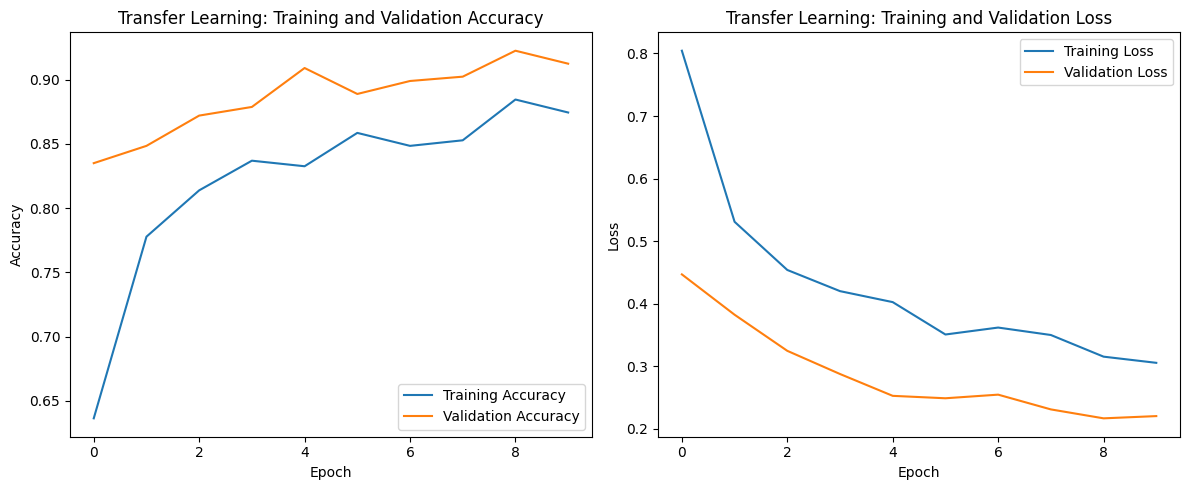

In [35]:
import matplotlib.pyplot as plt

# Extracting metrics from the history_transfer object
acc = history_transfer.history['accuracy']
val_acc = history_transfer.history['val_accuracy']
loss = history_transfer.history['loss']
val_loss = history_transfer.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Transfer Learning: Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Transfer Learning: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [36]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [37]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [38]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [39]:
history = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=20,

    callbacks=[
        early_stop,
        checkpoint
    ]

)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - accuracy: 0.8874 - loss: 0.2866 - val_accuracy: 0.9024 - val_loss: 0.2184
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.8658 - loss: 0.3326 - val_accuracy: 0.9327 - val_loss: 0.1882
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.8918 - loss: 0.2802 - val_accuracy: 0.9192 - val_loss: 0.1896
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.8947 - loss: 0.2869 - val_accuracy: 0.9259 - val_loss: 0.1903
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - accuracy: 0.9033 - loss: 0.2565 - val_accuracy: 0.9024 - val_loss: 0.2341
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.8990 - loss: 0.2425 - val_accuracy: 0.9327 - val_loss: 0.1672
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.8918 - loss: 0.2613 - val_accuracy: 0.9226 - val_loss: 0.1915
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.8860 - loss: 0.3208 - val_accuracy: 0.9562 

In [40]:
model.save("bean_model.h5")

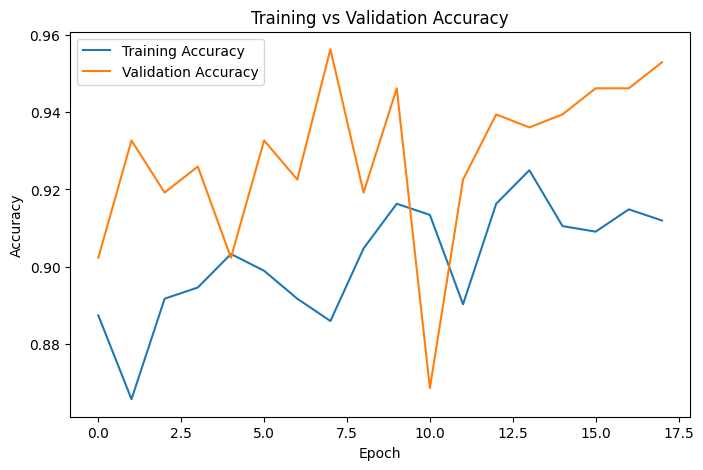

In [41]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

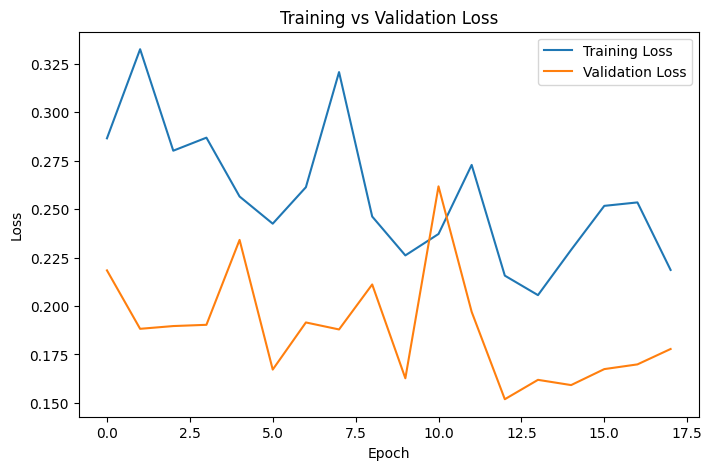

In [42]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [43]:
import tensorflow as tf

# Re-creating the test split from validation_dataset
# We take half of the validation batches for testing
val_batches = tf.data.experimental.cardinality(validation_dataset)
test_dataset = validation_dataset.take(val_batches // 2)
validation_dataset = validation_dataset.skip(val_batches // 2)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9500 - loss: 0.1328

Test Accuracy: 0.9500
Test Loss: 0.1328


In [44]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import numpy as np

In [45]:
y_true = np.concatenate([labels.numpy() for _, labels in test_dataset])

y_pred_probs = model.predict(test_dataset)

y_pred = np.argmax(y_pred_probs, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step


In [46]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                   precision    recall  f1-score   support

angular_leaf_spot       0.93      0.95      0.94        55
        bean_rust       0.90      0.90      0.90        42
          healthy       1.00      0.98      0.99        63

         accuracy                           0.95       160
        macro avg       0.94      0.94      0.94       160
     weighted avg       0.95      0.95      0.95       160



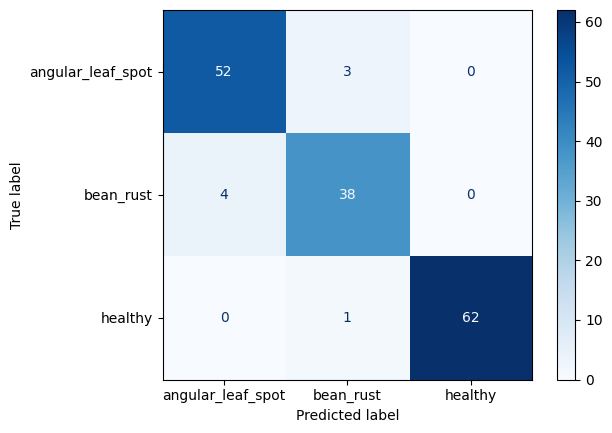

In [47]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")

plt.show()

In [48]:
import os

os.listdir("/content")

['.config',
 'bean-disease-dataset.zip',
 'Bean_Dataset',
 'plp.txt',
 'best_model.keras',
 'bean_model.h5',
 'sample_data']

In [49]:
!ls -lh /content

total 154M
drwxr-xr-x 5 root root 4.0K Jul 29 06:27 Bean_Dataset
-rw-r--r-- 1 root root 132M Oct 26  2022 bean-disease-dataset.zip
-rw-r--r-- 1 root root  11M Jul 29 06:30 bean_model.h5
-rw-r--r-- 1 root root  12M Jul 29 06:30 best_model.keras
-rw-r--r-- 1 root root   61 Jul 29 06:26 plp.txt
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data


In [50]:
from google.colab import files
files.download('/content/bean_model.h5')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted")
recall = recall_score(y_true, y_pred, average="weighted")
f1 = f1_score(y_true, y_pred, average="weighted")

print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print("=" * 40)

Accuracy : 0.9500
Precision: 0.9504
Recall   : 0.9500
F1-Score : 0.9502


In [52]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average="weighted"),
        recall_score(y_true, y_pred, average="weighted"),
        f1_score(y_true, y_pred, average="weighted")
    ]
})

metrics_df

,Metric,Score
0,Accuracy,0.950000
1,Precision,0.950446
2,Recall,0.950000
3,F1-Score,0.950172
